Understanding the problem

# 📌 Stochastic Gradient Descent (SGD) with Regularization: L1 (Lasso), L2 (Ridge), Elastic Net

## Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ✅ Load the Housing Dataset

In [3]:
url = "https://raw.githubusercontent.com/Phionanamugga/teaching/refs/heads/main/datasets/housing.csv"
df = pd.read_csv(url)

# ✅ Prepare Features (X) and Target (y)

In [4]:
X = df.iloc[:, :-1].values  
y = df.iloc[:, -1].values   

# ✅ Split into Training & Test Sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Normalize Features (Gradient Descent is sensitive to scaling)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ✅ Add Bias Term (X0 = 1) for Intercept

In [7]:
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# 🔹 1️⃣ SGD WITHOUT REGULARIZATION 🔹

In [8]:
def sgd_no_regularization(X, y, learning_rate=0.01, epochs=1000):
    m, n = X.shape
    theta = np.random.randn(n)  
    cost_history = []

    for epoch in range(epochs):
        random_index = np.random.randint(m)
        xi, yi = X[random_index:random_index+1], y[random_index:random_index+1]

        gradients = 2 * xi.T @ (xi @ theta - yi)
        theta -= learning_rate * gradients

        cost_history.append(mean_squared_error(y, X @ theta))

    return theta, cost_history

# 🔹 2️⃣ SGD WITH L1 REGULARIZATION (Lasso) 🔹

In [9]:
def sgd_l1(X, y, learning_rate=0.01, epochs=1000, alpha=0.01):
    m, n = X.shape
    theta = np.random.randn(n)  
    cost_history = []

    for epoch in range(epochs):
        random_index = np.random.randint(m)
        xi, yi = X[random_index:random_index+1], y[random_index:random_index+1]

        gradients = 2 * xi.T @ (xi @ theta - yi) + alpha * np.sign(theta)
        theta -= learning_rate * gradients

        cost_history.append(mean_squared_error(y, X @ theta))

    return theta, cost_history

# 🔹 3️⃣ SGD WITH L2 REGULARIZATION (Ridge) 🔹

In [10]:
def sgd_l2(X, y, learning_rate=0.01, epochs=1000, alpha=0.01):
    m, n = X.shape
    theta = np.random.randn(n)  
    cost_history = []

    for epoch in range(epochs):
        random_index = np.random.randint(m)
        xi, yi = X[random_index:random_index+1], y[random_index:random_index+1]

        gradients = 2 * xi.T @ (xi @ theta - yi) + alpha * theta
        theta -= learning_rate * gradients

        cost_history.append(mean_squared_error(y, X @ theta))

    return theta, cost_history

# 🔹 4️⃣ SGD WITH ELASTIC NET REGULARIZATION 🔹

In [11]:
def sgd_elastic_net(X, y, learning_rate=0.01, epochs=1000, alpha=0.01, l1_ratio=0.5):
    m, n = X.shape
    theta = np.random.randn(n)  
    cost_history = []

    for epoch in range(epochs):
        random_index = np.random.randint(m)
        xi, yi = X[random_index:random_index+1], y[random_index:random_index+1]

        l1_term = alpha * l1_ratio * np.sign(theta)  # L1 penalty
        l2_term = alpha * (1 - l1_ratio) * theta     # L2 penalty
        gradients = 2 * xi.T @ (xi @ theta - yi) + l1_term + l2_term
        theta -= learning_rate * gradients

        cost_history.append(mean_squared_error(y, X @ theta))

    return theta, cost_history

# ✅ Run all regularization strategies

In [12]:
regularizations = {
    "No Regularization": sgd_no_regularization,
    "L1 Regularization (Lasso)": sgd_l1,
    "L2 Regularization (Ridge)": sgd_l2,
    "Elastic Net Regularization": sgd_elastic_net
}

results = {}

for name, reg_func in regularizations.items():
    print(f"Running {name}...")
    theta, cost_history = reg_func(X_train_b, y_train)
    results[name] = (theta, cost_history)

Running No Regularization...
Running L1 Regularization (Lasso)...
Running L2 Regularization (Ridge)...
Running Elastic Net Regularization...


# ✅ Compare Models on Test Data

In [13]:
for name, (theta, _) in results.items():
    y_pred = X_test_b @ theta
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name} MSE: {mse:.4f}")

No Regularization MSE: 0.1854
L1 Regularization (Lasso) MSE: 0.1686
L2 Regularization (Ridge) MSE: 0.1680
Elastic Net Regularization MSE: 0.1807


# ✅ Visualization: Regularization Impact on Loss

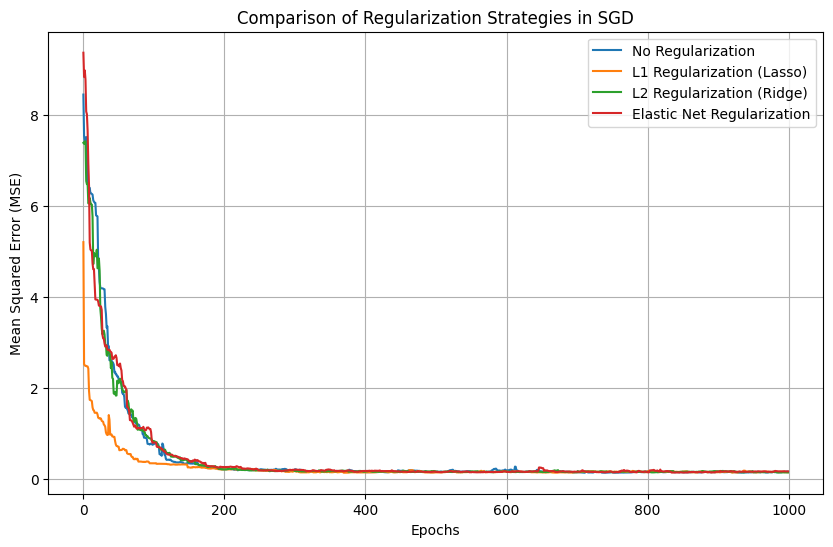

In [14]:
plt.figure(figsize=(10,6))
for name, (_, cost_history) in results.items():
    plt.plot(cost_history, label=name)

plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Comparison of Regularization Strategies in SGD")
plt.legend()
plt.grid()
plt.show()